<a href="https://colab.research.google.com/github/Andreas-Lukito/Stock_Sentiment_Analysis/blob/dev%2Fandreas/notebooks/01_text_cleaning_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# News Data Cleaning

## Import Libraries

In [1]:
# !pip install python-dotenv cloudscraper newspaper3k tqdm contractions emoji lxml_html_clean

In [11]:
# Common Libraries
import numpy as np
import pandas as pd
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt

# Cleaner output
from tqdm import tqdm
from IPython.display import clear_output

# Google Colab Setup
# from google.colab import drive
# drive.mount('/content/drive')
# project_path = "/content/drive/MyDrive/stock_news_sentiment_analysis"

project_path = ".."

## Add the path to text preprocessor
sys.path.append(os.path.abspath(os.path.join(project_path, "lib")))

# Text preprocessing
from preprocessor import clean_text
from scraper import extract_text_from_url, scrape_dataframe

## Import the dataset

In [3]:
news_data = pd.read_csv(os.path.join(project_path, "news_cache/catgorized_data/categorized_news_data_refetched.csv"), sep=",")

##

In [4]:
news_data.head()

,index,uuid,title,description,keywords,snippet,url,image_url,language,published_at,source,relevance_score,entities,similar,sentiment,text,clean_text,categorical_sentiment_3_class,length
0,0,487e6a88-d3c2-4ae1-8dc2-26af6b31d688,2025: The Year Of Alphabet (GOOG),No stock has seen a bigger jump recently than ...,NaN,vzphotos/iStock Editorial via Getty Images\n\n...,https://seekingalpha.com/article/4848680-2025-...,https://static.seekingalpha.com/cdn/s3/uploads...,en,2025-11-30T05:30:00.000000Z,seekingalpha.com,NaN,"[{'symbol': 'GOOGL', 'name': 'Alphabet Inc.', ...",[],0.0000,2025: The Year Of Alphabet (GOOG) No stock has...,vzphotos istock editorial via getty images sin...,neutral,42
1,1,92b5c2bd-d324-4ae8-b115-2cfd95a8fa98,Why I'm Doubling Down On My Adobe Position (NA...,"Adobe's revenue is highly predictable, driven ...",NaN,To say that Adobe ( ADBE ) stock has not had a...,https://seekingalpha.com/article/4848762-why-i...,https://static.seekingalpha.com/cdn/s3/uploads...,en,2025-11-30T05:25:01.000000Z,seekingalpha.com,NaN,"[{'symbol': 'ADBE', 'name': 'Adobe Inc.', 'exc...",[],0.0000,Why I'm Doubling Down On My Adobe Position (NA...,to say that adobe adbe stock has not had a goo...,neutral,259
2,2,9084e5f1-75f5-4f15-aa3d-0676073b4aaf,Global week ahead: The start of a Santa Rally ...,NaN,"STOXX 600, business news",And just like that... December is upon us. It'...,https://www.cnbc.com/2025/11/30/global-week-ah...,https://image.cnbcfm.com/api/v1/image/10823257...,en,2025-11-30T05:10:58.000000Z,cnbc.com,NaN,"[{'symbol': 'M', 'name': ""Macy's, Inc."", 'exch...",[],0.6908,Global week ahead: The start of a Santa Rally ...,and just like that december is upon us it is b...,positive,493
3,3,487e6a88-d3c2-4ae1-8dc2-26af6b31d688,2025: The Year Of Alphabet (GOOG),No stock has seen a bigger jump recently than ...,NaN,vzphotos/iStock Editorial via Getty Images\n\n...,https://seekingalpha.com/article/4848680-2025-...,https://static.seekingalpha.com/cdn/s3/uploads...,en,2025-11-30T05:30:00.000000Z,seekingalpha.com,NaN,"[{'symbol': 'GOOGL', 'name': 'Alphabet Inc.', ...",[],0.0000,2025: The Year Of Alphabet (GOOG) No stock has...,vzphotos istock editorial via getty images sin...,neutral,42
4,4,92b5c2bd-d324-4ae8-b115-2cfd95a8fa98,Why I'm Doubling Down On My Adobe Position (NA...,"Adobe's revenue is highly predictable, driven ...",NaN,To say that Adobe ( ADBE ) stock has not had a...,https://seekingalpha.com/article/4848762-why-i...,https://static.seekingalpha.com/cdn/s3/uploads...,en,2025-11-30T05:25:01.000000Z,seekingalpha.com,NaN,"[{'symbol': 'ADBE', 'name': 'Adobe Inc.', 'exc...",[],0.0000,Why I'm Doubling Down On My Adobe Position (NA...,to say that adobe adbe stock has not had a goo...,neutral,259


## Fix the `Text` Columns

Since the `text` columns contains blocked bot messages as follows:
1. this page either does not exist or is currently unavailable from here you can either hit the back button on your browser to return to the previous page or visit the abcnews com home page you can also search for something on our site below status code 404

2. checking your browser this may take a few seconds

3. it seems like you are already an etprime member with login using your et prime credentials to enjoy all member benefits log out of your current logged in account and log in again using your et prime credentials to enjoy all member benefits

In [5]:
BOT_SIGNALS = [
    # cloudflare / generic bot checks
    "checking your browser",
    "enable javascript",
    "please wait",
    "captcha",
    "automated access",
    
    # paywalls / login walls
    "et prime member",
    "log in again",
    "member benefits",
    "subscribe to continue",
    "subscription required",
    
    # 404 / missing pages
    "does not exist or is currently unavailable",
    "hit the back button",
    "visit the abcnews com home page",
    "page not found",
    
    # generic short/useless responses
]

MIN_TEXT_LENGTH = 200  # anything shorter is likely junk

def is_bad_text(text: str) -> bool:
    lowered = text.lower()
    return any(signal in lowered for signal in BOT_SIGNALS)

In [6]:
before = len(news_data)

# flag bad rows
news_data["is_bad"] = news_data["text"].apply(
    lambda t: is_bad_text(str(t)) if pd.notna(t) else True
)

bad_df = news_data[news_data["is_bad"]].copy()
clean_df = news_data[~news_data["is_bad"]].copy().drop(columns=["is_bad"])

print(f"Total rows:   {before}")
print(f"Bad rows:     {len(bad_df)}")
print(f"Clean rows:   {len(clean_df)}")

Total rows:   77088
Bad rows:     2828
Clean rows:   74260


In [7]:
bad_df

,index,uuid,title,description,keywords,snippet,url,image_url,language,published_at,source,relevance_score,entities,similar,sentiment,text,clean_text,categorical_sentiment_3_class,length,is_bad
30,30,0b6c91fc-ea1b-4c1b-aa8f-171f1c91d385,Grupo Financiero Galicia S.A. 2025 Q3 - Result...,2025-11-29. The following slide deck was publi...,NaN,"To ensure this doesn’t happen in the future, p...",https://seekingalpha.com/article/4848748-grupo...,https://static.seekingalpha.com/assets/og_imag...,en,2025-11-29T23:09:42.000000Z,seekingalpha.com,NaN,"[{'symbol': 'GGABF', 'name': 'Grupo Financiero...",[],0.0,Grupo Financiero Galicia S.A. 2025 Q3 - Result...,to ensure this doesn t happen in the future pl...,neutral,34,True
32,32,df0f5081-6181-44e0-a5d1-a473978187c0,Griffon Corporation 2025 Q4 - Results - Earnin...,2025-11-29. The following slide deck was publi...,NaN,"To ensure this doesn’t happen in the future, p...",https://seekingalpha.com/article/4848746-griff...,https://static.seekingalpha.com/assets/og_imag...,en,2025-11-29T23:01:52.000000Z,seekingalpha.com,NaN,"[{'symbol': 'GFF', 'name': 'Griffon Corporatio...",[],0.0,Griffon Corporation 2025 Q4 - Results - Earnin...,to ensure this doesn t happen in the future pl...,neutral,34,True
192,192,ce539f76-3da1-48bd-99a1-bfb45e437ac5,"Itron, Inc. 2025 Q3 - Results - Earnings Call ...",2025-11-29. The following slide deck was publi...,NaN,"To ensure this doesn’t happen in the future, p...",https://seekingalpha.com/article/4848717-itron...,https://static.seekingalpha.com/assets/og_imag...,en,2025-11-29T10:33:49.000000Z,seekingalpha.com,NaN,"[{'symbol': 'ITRI', 'name': 'Itron, Inc.', 'ex...",[],0.0,"Itron, Inc. 2025 Q3 - Results - Earnings Call ...",to ensure this doesn t happen in the future pl...,neutral,34,True
208,208,d26267f2-afed-48bd-88a4-57fddb199624,"Hub Group, Inc. 2025 Q3 - Results - Earnings C...",2025-11-29. The following slide deck was publi...,NaN,"To ensure this doesn’t happen in the future, p...",https://seekingalpha.com/article/4848700-hub-g...,https://static.seekingalpha.com/assets/og_imag...,en,2025-11-29T08:23:59.000000Z,seekingalpha.com,NaN,"[{'symbol': 'HUBG', 'name': 'Hub Group, Inc.',...",[],0.0,"Hub Group, Inc. 2025 Q3 - Results - Earnings C...",to ensure this doesn t happen in the future pl...,neutral,34,True
219,219,bb55d275-c148-4b66-b122-183aba536c18,"National CineMedia, Inc. 2025 Q3 - Results - E...",2025-11-29. The following slide deck was publi...,NaN,"To ensure this doesn’t happen in the future, p...",https://seekingalpha.com/article/4848692-natio...,https://static.seekingalpha.com/assets/og_imag...,en,2025-11-29T07:23:41.000000Z,seekingalpha.com,NaN,"[{'symbol': 'NCMI', 'name': 'National CineMedi...",[],0.0,"National CineMedia, Inc. 2025 Q3 - Results - E...",to ensure this doesn t happen in the future pl...,neutral,34,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76641,76641,37405da3-0f5e-4bb4-a47a-c200a2d4f33e,Indices: Stock market update: Nifty Pharma ind...,The Nifty Pharma index closed 0.22 per cent d...,"Indices, Indices stocks, Indices news, Indices...",It seems like you're already an ETPrime member...,https://economictimes.indiatimes.com/markets/s...,"https://img.etimg.com/thumb/msid-83721067,widt...",en,2025-06-02T10:40:58.000000Z,economictimes.indiatimes.com,NaN,"[{'symbol': '^CNXPHARMA', 'name': 'Nifty Pharm...",[],0.0,Indices: Stock market update: Nifty Pharma ind...,it seems like you are already an etprime membe...,neutral,41,True
76871,76871,500bb330-6929-4c0f-a454-79b7e69b8956,"Apollo Hospitals to invest Rs 6,000 crore for ...",Apollo Hospitals has unveiled plans for a mass...,"apollo hospitals, Apollo Hospitals investment,...",It seems like you're already an ETPrime member...,https://economictimes.indiatimes.com/markets/s...,"https://img.etimg.com/thumb/msid-121521117,wid...",en,2025-05-30T16:11:59.000000Z,economictimes.indiatimes.com,NaN,"[{'symbol': 'APOLLOHOSP-BL.NS', 'name': 'APOLL...",[],0.0,"Apoll

## Text Cleaning

In [8]:

categorized_data_path = os.path.join(project_path,f"news_cache/catgorized_data/categorized_news_data_rescraped_cleaned.csv")
categorized_data_path_folder = os.path.join(project_path,f"news_cache/catgorized_data/")
os.makedirs(categorized_data_path_folder, exist_ok=True)
overwrite_clean_data = True


In [9]:
# tqdm for cleaner output
tqdm.pandas(desc="Cleaning the Text", unit="news")

# We will cache the data so that it will load faster
if os.path.exists(categorized_data_path) and not overwrite_clean_data:
    print("Loading cached dataset...")
    clean_df = pd.read_csv(categorized_data_path)
    print("Cached dataset loaded")

elif os.path.exists(categorized_data_path) and overwrite_clean_data:
    print("Overwriting old data and caching new data...")
    # Clean the data
    clean_df["clean_text"] = clean_df["text"].progress_apply(
                                                        lambda x: clean_text(
                                                            text = x,
                                                            tokenize=False,
                                                            remove_stop_words= False, # Since we will be using a transformer model, we will not remove stop words since it can be useful for the model to understand the context of the sentence.
                                                            remove_emojis="keep"
                                                            )
                                                        )
    clean_df.to_csv(categorized_data_path, index=False)
    print("Done Overwriting old data and caching new data...")

else:
    print("Creating and caching dataset...")
    # Clean the data
    clean_df["clean_text"] = clean_df["text"].progress_apply(
                                                        lambda x: clean_text(
                                                            text = x,
                                                            tokenize=False,
                                                            remove_stop_words= False,
                                                            remove_emojis="keep"
                                                            )
                                                        )
    clean_df.to_csv(categorized_data_path, index=False)
    print("Finished Caching")

Creating and caching dataset...


Cleaning the Text: 100%|██████████| 74260/74260 [00:26<00:00, 2848.12news/s]


Finished Caching


/tmp/ipykernel_172306/4235828932.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clean_df, x="categorical_sentiment_3_class", order=["positive", "negative", "neutral"], palette="Set2")


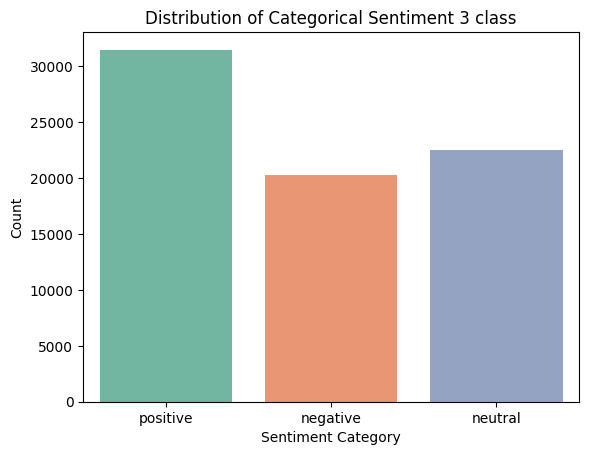

In [12]:
sns.countplot(data=clean_df, x="categorical_sentiment_3_class", order=["positive", "negative", "neutral"], palette="Set2")
plt.title("Distribution of Categorical Sentiment 3 class")
plt.xlabel("Sentiment Category")
plt.ylabel("Count")
plt.show()